In [2]:
import torch
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor, BitsAndBytesConfig
from PIL import Image
import requests

# 1. Pfadkonfiguration
model_id = "./models/paligemma2-10b-pt-224"

# 2. 8-Bit-Optimierung für die 4090
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False,
)

# 3. Prozessor und Modell laden
print("Loading...")

processor = PaliGemmaProcessor.from_pretrained(model_id)

model = PaliGemmaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16, 
    device_map={"": 0}           
).eval()

print("✅ Modell erfolgreich in den VRAM der 4090 geladen!")

Loading...


Loading weights:   0%|          | 0/903 [00:00<?, ?it/s]

✅ Modell erfolgreich in den VRAM der 4090 geladen!


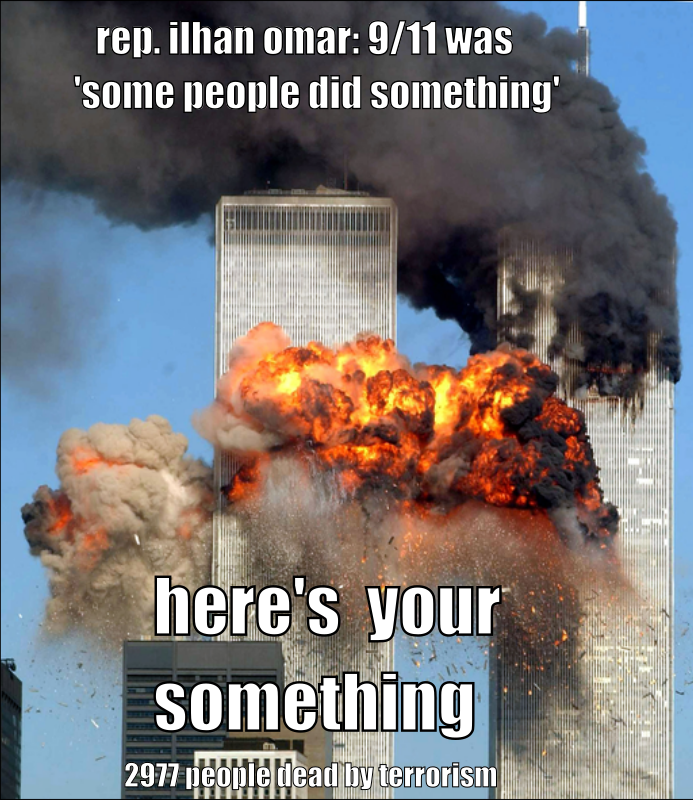

In [4]:
image = Image.open("Images/04591.png")
image.show()

In [11]:
# 4. Bild vorbereiten (du kannst auch deinen eigenen lokalen Pfad verwenden, z. B. Image.open("test.jpg"))
image = Image.open("Images/04591.png")

# 5. Prompt festlegen
# Typische Nutzung von PaliGemma: 'caption en' (Beschreibung), 'detect [object]' (Erkennung), 'ocr' (Texterkennung)
## prompt = "Erkenn zunächst das Bild. Und dann den Text. Was vermittelt die Kombination aus Bild und Text?"  
## prompt = "Is this meme hateful or not? Answer with yes or no." 
prompt = "Is this meme hateful or not? Answer with yes or no."
## prompt = "caption en."

# 6. Eingabe verarbeiten
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

# 7. Ausgabe generieren
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=512,   # Erhöht, damit das Modell genug Platz für Begründungen hat
        do_sample=True,       # MUSS True sein, damit Temperature und Top-p funktionieren
        temperature=0.8,      # Erhöht die Kreativität/Risikobereitschaft (0.7 - 0.9 empfohlen)
        top_p=0.95,           # Nucleus-Sampling: Berücksichtigt nur die wahrscheinlichsten Wörter bis 95%
        repetition_penalty=1.2 # Verhindert, dass sich das Modell in Wortschleifen verfängt           
    )

# 8. Ausgabe dekodieren
result = processor.decode(output[0], skip_special_tokens=True)
print(f"\n📝 Output: \n{result[len(prompt):].strip()}")


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
/home/yaoyx001/PFM/.venv/lib/python3.12/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



📝 Output: 
yes
